# MLB Pitcher Pitch-Type Analysis: 2025 and 2026

This notebook is separate from the prediction process. It pulls or loads pitch-level Statcast data, summarizes it by pitcher and pitch type, creates plot-ready tables, and provides analysis helpers.

Outputs are saved under `pitch_analysis_outputs/`:

- `pitcher_pitch_type_summary_2025_2026.csv`
- `pitcher_arsenal_summary_2025_2026.csv`
- `pitcher_pitch_type_yoy_changes_2025_2026.csv`
- `pitcher_pitch_type_recent_30d.csv`
- optional raw parquet cache if you fetch Statcast data

The notebook will first try to load raw Statcast data from your export zip or folder. If raw Statcast is not present, it can fetch pitch-level data via `pybaseball.statcast()` in chunks.

In [4]:
# Optional install if needed:
%pip install pybaseball pyarrow tqdm scikit-learn matplotlib pandas numpy

from pathlib import Path
from datetime import date, timedelta
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("pitch_analysis_outputs")
RAW_DIR = OUTPUT_DIR / "raw"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"

for p in [OUTPUT_DIR, RAW_DIR, TABLE_DIR, PLOT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Date range. 2026 end date defaults to yesterday so today's incomplete games are excluded.
START_DATE = "2025-01-01"
END_DATE = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")

# Optional: point this to your local export zip or extracted export folder.
# Example:
# EXPORT_ZIP = Path("C:/Users/rfo7799/Desktop/Git/TetheredAI/MLB/mlb_betting_app/export_data/mlb_data_export_2023-01-01_to_2026-06-17.zip")
EXPORT_ZIP = None
EXPORT_DIR = None

# Fetch options if raw Statcast is not found in existing export.
FETCH_STATCAST_IF_MISSING = True
FETCH_CHUNK_DAYS = 7
REGULAR_SEASON_ONLY = True
MIN_PITCHES_FOR_SUMMARY = 25

RANDOM_STATE = 42

print("Date range:", START_DATE, "to", END_DATE)
print("Output directory:", OUTPUT_DIR.resolve())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.1 MB/s eta 0:00:00
Date range: 2025-01-01 to 2026-06-15
Output directory: /content/pitch_analysis_outputs


## 1. Load raw Statcast if available, otherwise fetch it

The modeling `features` parquet is game-level. For pitcher-by-pitch-type plots, we need pitch-level Statcast rows containing fields such as `pitcher`, `player_name`, `pitch_type`, `release_speed`, `release_spin_rate`, `pfx_x`, `pfx_z`, `description`, and batted-ball columns.

In [5]:
def list_statcast_files_in_zip(export_zip):
    if export_zip is None:
        return []
    export_zip = Path(export_zip)
    if not export_zip.exists():
        return []
    with zipfile.ZipFile(export_zip, "r") as z:
        return [n for n in z.namelist() if "statcast" in n.lower() and n.lower().endswith((".parquet", ".csv"))]


def find_statcast_file_in_dir(export_dir):
    if export_dir is None:
        return None
    export_dir = Path(export_dir)
    if not export_dir.exists():
        return None
    candidates = [p for p in export_dir.rglob("*") if "statcast" in p.name.lower() and p.suffix.lower() in {".parquet", ".csv"}]
    if not candidates:
        return None
    # Prefer raw pitch-level looking files.
    candidates = sorted(candidates, key=lambda p: ("raw" not in str(p).lower(), p.stat().st_size), reverse=False)
    return candidates[0]


def read_statcast_file(path):
    path = Path(path)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported file type: {path}")


def load_statcast_from_export(export_zip=None, export_dir=None):
    # Try extracted folder first.
    p = find_statcast_file_in_dir(export_dir)
    if p is not None:
        print("Loading Statcast from extracted export:", p)
        return read_statcast_file(p)

    # Try zip.
    if export_zip is not None and Path(export_zip).exists():
        files = list_statcast_files_in_zip(export_zip)
        print("Statcast files in export zip:", files)
        if files:
            # Prefer raw-looking parquet.
            files_sorted = sorted(files, key=lambda x: ("raw" not in x.lower(), not x.lower().endswith(".parquet"), len(x)))
            chosen = files_sorted[0]
            extract_root = RAW_DIR / "export_extract"
            extract_root.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(export_zip, "r") as z:
                z.extract(chosen, extract_root)
            extracted_path = extract_root / chosen
            print("Loading Statcast from zip member:", chosen)
            return read_statcast_file(extracted_path)

    return None


statcast_raw = load_statcast_from_export(EXPORT_ZIP, EXPORT_DIR)

if statcast_raw is None:
    print("No raw Statcast file found in export. Will fetch if FETCH_STATCAST_IF_MISSING=True.")
else:
    print("Loaded statcast_raw:", statcast_raw.shape)
    display(statcast_raw.head())

No raw Statcast file found in export. Will fetch if FETCH_STATCAST_IF_MISSING=True.


In [6]:
def date_chunks(start_date, end_date, chunk_days=7):
    start = pd.to_datetime(start_date).date()
    end = pd.to_datetime(end_date).date()
    cur = start
    while cur <= end:
        chunk_end = min(cur + timedelta(days=chunk_days - 1), end)
        yield cur.strftime("%Y-%m-%d"), chunk_end.strftime("%Y-%m-%d")
        cur = chunk_end + timedelta(days=1)


def fetch_statcast_pitch_level(start_date, end_date, chunk_days=7, cache_dir=RAW_DIR):
    """Fetch pitch-level Statcast data in small chunks and cache each chunk as parquet."""
    try:
        from pybaseball import statcast
        try:
            from pybaseball import cache
            cache.enable()
        except Exception:
            pass
    except Exception as e:
        raise ImportError("pybaseball is required. Install with: pip install pybaseball") from e

    frames = []
    chunks = list(date_chunks(start_date, end_date, chunk_days=chunk_days))

    for start, end in chunks:
        cache_path = cache_dir / f"statcast_{start}_to_{end}.parquet"
        if cache_path.exists():
            print("Loading cached", cache_path.name)
            df = pd.read_parquet(cache_path)
        else:
            print("Fetching", start, "to", end)
            df = statcast(start_dt=start, end_dt=end)
            df.to_parquet(cache_path, index=False)
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    out = pd.concat(frames, ignore_index=True, sort=False)
    out = out.drop_duplicates()
    return out


if statcast_raw is None and FETCH_STATCAST_IF_MISSING:
    statcast_raw = fetch_statcast_pitch_level(
        START_DATE,
        END_DATE,
        chunk_days=FETCH_CHUNK_DAYS,
        cache_dir=RAW_DIR,
    )
    raw_cache_path = RAW_DIR / f"statcast_pitch_level_{START_DATE}_to_{END_DATE}.parquet"
    statcast_raw.to_parquet(raw_cache_path, index=False)
    print("Saved raw pitch-level cache:", raw_cache_path.resolve())

print("statcast_raw available:", statcast_raw is not None)
if statcast_raw is not None:
    print("statcast_raw shape:", statcast_raw.shape)
    display(pd.DataFrame({"column": statcast_raw.columns}).head(150))

Fetching 2025-01-01 to 2025-01-07
This is a large query, it may take a moment to complete
Skipping offseason dates


0it [00:00, ?it/s]

Fetching 2025-01-08 to 2025-01-14
This is a large query, it may take a moment to complete


Skipping offseason dates


0it [00:00, ?it/s]

...

100%|██████████| 7/7 [00:08<00:00,  1.24s/it]


Fetching 2026-06-10 to 2026-06-15
This is a large query, it may take a moment to complete


100%|██████████| 6/6 [00:06<00:00,  1.07s/it]


Saved raw pitch-level cache: /content/pitch_analysis_outputs/raw/statcast_pitch_level_2025-01-01_to_2026-06-15.parquet
statcast_raw available: True
statcast_raw shape: (1127432, 119)


,column
0,pitch_type
1,game_date
2,release_speed
3,release_pos_x
4,release_pos_z
...,...
114,attack_angle
115,attack_direction
116,swing_path_tilt
117,intercept_ball_minus_batter_pos_x_inches


## 2. Clean pitch-level data

This section keeps regular-season pitches if requested, creates pitch-type labels, and derives common pitch outcomes such as whiffs, called strikes, CSW, zone, chase, batted balls, hard-hit, and barrels.

In [7]:
PITCH_TYPE_MAP = {
    "FF": "4-Seam Fastball",
    "SI": "Sinker",
    "FC": "Cutter",
    "SL": "Slider",
    "ST": "Sweeper",
    "CU": "Curveball",
    "KC": "Knuckle Curve",
    "CH": "Changeup",
    "FS": "Splitter",
    "FO": "Forkball",
    "SC": "Screwball",
    "KN": "Knuckleball",
    "EP": "Eephus",
    "SV": "Slurve",
    "FA": "Fastball",
    "FT": "2-Seam Fastball",
    "PO": "Pitchout",
    "IN": "Intentional Ball",
}

SWING_DESCRIPTIONS = {
    "swinging_strike", "swinging_strike_blocked", "foul", "foul_tip", "foul_bunt",
    "hit_into_play", "hit_into_play_no_out", "hit_into_play_score", "missed_bunt",
}

WHIFF_DESCRIPTIONS = {"swinging_strike", "swinging_strike_blocked", "missed_bunt"}
CALLED_STRIKE_DESCRIPTIONS = {"called_strike"}
BATTED_BALL_DESCRIPTIONS = {"hit_into_play", "hit_into_play_no_out", "hit_into_play_score"}


def prepare_pitch_level(df):
    if df is None or df.empty:
        raise ValueError("No statcast_raw data available. Set EXPORT_ZIP/EXPORT_DIR or enable FETCH_STATCAST_IF_MISSING.")

    d = df.copy()

    required = ["pitcher", "player_name", "pitch_type", "game_date"]
    missing = [c for c in required if c not in d.columns]
    if missing:
        raise ValueError(f"Statcast data is missing required columns: {missing}")

    d["game_date"] = pd.to_datetime(d["game_date"], errors="coerce")
    d["season"] = d["game_date"].dt.year

    d = d[d["season"].isin([2025, 2026])].copy()

    if REGULAR_SEASON_ONLY and "game_type" in d.columns:
        d = d[d["game_type"].astype(str).eq("R")].copy()

    d = d[d["pitcher"].notna() & d["pitch_type"].notna()].copy()

    d["pitcher"] = pd.to_numeric(d["pitcher"], errors="coerce").astype("Int64")
    d["player_name"] = d["player_name"].astype(str)
    d["pitch_type"] = d["pitch_type"].astype(str)
    d["pitch_name"] = d["pitch_type"].map(PITCH_TYPE_MAP).fillna(d["pitch_type"])

    desc = d["description"].astype(str) if "description" in d.columns else pd.Series("", index=d.index)
    d["is_swing"] = desc.isin(SWING_DESCRIPTIONS).astype(float)
    d["is_whiff"] = desc.isin(WHIFF_DESCRIPTIONS).astype(float)
    d["is_called_strike"] = desc.isin(CALLED_STRIKE_DESCRIPTIONS).astype(float)
    d["is_csw"] = ((d["is_whiff"].eq(1)) | (d["is_called_strike"].eq(1))).astype(float)
    d["is_batted_ball"] = desc.isin(BATTED_BALL_DESCRIPTIONS).astype(float)

    if "zone" in d.columns:
        d["zone_num"] = pd.to_numeric(d["zone"], errors="coerce")
        d["is_zone"] = d["zone_num"].between(1, 9).astype(float)
        d["is_chase"] = ((d["is_zone"].eq(0)) & (d["is_swing"].eq(1))).astype(float)
    else:
        d["is_zone"] = np.nan
        d["is_chase"] = np.nan

    if "launch_speed" in d.columns:
        ls = pd.to_numeric(d["launch_speed"], errors="coerce")
        d["is_hard_hit"] = ((ls >= 95) & d["is_batted_ball"].eq(1)).astype(float)
    else:
        d["is_hard_hit"] = np.nan

    if "launch_speed_angle" in d.columns:
        # In Baseball Savant data, launch_speed_angle == 6 commonly indicates a barrel classification.
        d["is_barrel"] = ((pd.to_numeric(d["launch_speed_angle"], errors="coerce") == 6) & d["is_batted_ball"].eq(1)).astype(float)
    else:
        d["is_barrel"] = np.nan

    numeric_cols = [
        "release_speed", "release_spin_rate", "effective_speed", "release_extension",
        "pfx_x", "pfx_z", "plate_x", "plate_z", "release_pos_x", "release_pos_z",
        "launch_speed", "launch_angle", "estimated_woba_using_speedangle", "woba_value",
    ]
    for c in numeric_cols:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    return d


pitch_df = prepare_pitch_level(statcast_raw)

print("pitch_df shape:", pitch_df.shape)
print("date range:", pitch_df["game_date"].min(), "to", pitch_df["game_date"].max())
print("seasons:", sorted(pitch_df["season"].dropna().unique()))
print("pitch types:", sorted(pitch_df["pitch_type"].dropna().unique()))

display(pitch_df.head())

pitch_df shape: (1027306, 130)
date range: 2025-03-18 00:00:00 to 2026-06-15 00:00:00
seasons: [np.int32(2025), np.int32(2026)]
pitch types: ['CH', 'CS', 'CU', 'EP', 'FA', 'FC', 'FF', 'FO', 'FS', 'KC', 'KN', 'PO', 'SC', 'SI', 'SL', 'ST', 'SV', 'UN']


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,is_swing,is_whiff,is_called_strike,is_csw,is_batted_ball,zone_num,is_zone,is_chase,is_hard_hit,is_barrel
3189,FF,2025-03-18,97.7,2.68,5.35,"Scott, Tanner",807713,656945,strikeout,swinging_strike,...,1.0,1.0,0.0,1.0,0.0,3,1.0,0.0,0.0,0.0
3190,FF,2025-03-18,96.4,2.51,5.43,"Scott, Tanner",807713,656945,NaN,swinging_strike,...,1.0,1.0,0.0,1.0,0.0,2,1.0,0.0,0.0,0.0
3191,FF,2025-03-18,96.8,2.51,5.41,"Scott, Tanner",807713,656945,NaN,foul,...,1.0,0.0,0.0,0.0,0.0,5,1.0,0.0,0.0,0.0
3192,FF,2025-03-18,97.1,2.67,5.34,"Scott, Tanner",457759,656945,field_out,hit_into_play,...,1.0,0.0,0.0,0.0,1.0,5,1.0,0.0,0.0,0.0
3193,SL,2025-03-18,88.6,2.73,5.31,"Scott, Tanner",457759,656945,NaN,foul,...,1.0,0.0,0.0,0.0,0.0,13,0.0,1.0,0.0,0.0


## 3. Aggregate by pitcher and pitch type

This produces the primary plot-ready table.

In [8]:
def safe_rate(num, denom):
    return np.where(denom > 0, num / denom, np.nan)


def summarize_pitcher_pitch_type(pitch_df, group_cols=("season", "pitcher", "player_name", "pitch_type", "pitch_name")):
    d = pitch_df.copy()

    agg_spec = {
        "pitches": ("pitch_type", "count"),
        "games": ("game_date", "nunique"),
        "swings": ("is_swing", "sum"),
        "whiffs": ("is_whiff", "sum"),
        "called_strikes": ("is_called_strike", "sum"),
        "csw": ("is_csw", "sum"),
        "zone_pitches": ("is_zone", "sum"),
        "chases": ("is_chase", "sum"),
        "batted_balls": ("is_batted_ball", "sum"),
        "hard_hits": ("is_hard_hit", "sum"),
        "barrels": ("is_barrel", "sum"),
    }

    optional_means = [
        "release_speed", "release_spin_rate", "effective_speed", "release_extension",
        "pfx_x", "pfx_z", "plate_x", "plate_z", "release_pos_x", "release_pos_z",
        "launch_speed", "launch_angle", "estimated_woba_using_speedangle", "woba_value",
    ]

    for c in optional_means:
        if c in d.columns:
            agg_spec[f"avg_{c}"] = (c, "mean")
            agg_spec[f"max_{c}"] = (c, "max")

    out = d.groupby(list(group_cols), dropna=False).agg(**agg_spec).reset_index()

    out["usage_share_within_pitcher_season"] = out["pitches"] / out.groupby(["season", "pitcher"])["pitches"].transform("sum")
    out["whiff_rate"] = safe_rate(out["whiffs"], out["swings"])
    out["called_strike_rate"] = safe_rate(out["called_strikes"], out["pitches"])
    out["csw_rate"] = safe_rate(out["csw"], out["pitches"])
    out["zone_rate"] = safe_rate(out["zone_pitches"], out["pitches"])
    out["chase_rate"] = safe_rate(out["chases"], out["pitches"] - out["zone_pitches"])
    out["hard_hit_rate"] = safe_rate(out["hard_hits"], out["batted_balls"])
    out["barrel_rate"] = safe_rate(out["barrels"], out["batted_balls"])

    sort_cols = ["season", "player_name", "pitches"]
    out = out.sort_values(sort_cols, ascending=[True, True, False]).reset_index(drop=True)
    return out


pitcher_pitch_type_summary = summarize_pitcher_pitch_type(pitch_df)

summary_path = TABLE_DIR / "pitcher_pitch_type_summary_2025_2026.csv"
pitcher_pitch_type_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path.resolve())
print("summary shape:", pitcher_pitch_type_summary.shape)
display(pitcher_pitch_type_summary.head(50))

Saved: /content/pitch_analysis_outputs/tables/pitcher_pitch_type_summary_2025_2026.csv
summary shape: (7075, 52)


,season,pitcher,player_name,pitch_type,pitch_name,pitches,games,swings,whiffs,called_strikes,...,avg_woba_value,max_woba_value,usage_share_within_pitcher_season,whiff_rate,called_strike_rate,csw_rate,zone_rate,chase_rate,hard_hit_rate,barrel_rate
0,2025,671096,"Abbott, Andrew",FF,4-Seam Fastball,1263,29,597.0,102.0,258.0,...,0.299091,2.0,0.471797,0.170854,0.204276,0.285036,0.557403,0.252236,0.407240,0.085973
1,2025,671096,"Abbott, Andrew",CH,Changeup,526,29,286.0,68.0,43.0,...,0.274351,2.0,0.196489,0.237762,0.081749,0.211027,0.378327,0.403670,0.227642,0.089431
2,2025,671096,"Abbott, Andrew",ST,Sweeper,465,28,267.0,86.0,47.0,...,0.249194,2.0,0.173702,0.322097,0.101075,0.286022,0.513978,0.353982,0.301205,0.072289
3,2025,671096,"Abbott, Andrew",CU,Curveball,308,29,118.0,24.0,77.0,...,0.339623,2.0,0.115054,0.203390,0.250000,0.327922,0.522727,0.176871,0.302326,0.000000
4,2025,671096,"Abbott, Andrew",FC,Cutter,115,23,71.0,16.0,9.0,...,0.53913,2.0,0.042959,0.225352,0.078261,0.217391,0.539130,0.339623,0.473684,0.157895
5,2025,690953,"Abel, Mick",FF,4-Seam Fastball,303,10,162.0,36.0,39.0,...,0.439041,2.0,0.420833,0.222222,0.128713,0.247525,0.574257,0.286822,0.431818,0.159091
6,2025,690953,"Abel, Mick",CU,Curveball,154,10,64.0,22.0,30.0,...,0.247143,2.0,0.213889,0.343750,0.194805,0.337662,0.435065,0.298851,0.526316,0.052632
7,2025,690953,"Abel, Mick",SI,Sinker,95,10,49.0,6.0,15.0,...,0.426923,1.6,0.131944,0.122449,0.157895,0.221053,0.621053,0.277778,0.391304,0.000000
8,2025,690953,"Abel, Mick",SL,Slider,83,10,43.0,7.0,17.0,...,0.226087,0.9,0.115278,0.162791,0.204819,0.289157,0.614458,0.312500,0.736842,0.052632
9,2025,690953,"Abel, Mick",CH,Changeup,63,9,28.0,6.0,4.0,...,0.375,0.9,0.087500,0.214286,0.063492,0.158730,0.412698,0.162162,0.500000,0.100000


In [9]:
def summarize_pitcher_arsenal(pitcher_pitch_type_summary):
    d = pitcher_pitch_type_summary.copy()

    # Top pitch by usage and core arsenal shape.
    d = d.sort_values(["season", "pitcher", "usage_share_within_pitcher_season"], ascending=[True, True, False])

    rows = []
    for (season, pitcher, player_name), g in d.groupby(["season", "pitcher", "player_name"]):
        g = g.sort_values("usage_share_within_pitcher_season", ascending=False)
        row = {
            "season": season,
            "pitcher": pitcher,
            "player_name": player_name,
            "total_pitches": g["pitches"].sum(),
            "n_pitch_types": g["pitch_type"].nunique(),
            "primary_pitch_type": g.iloc[0]["pitch_type"],
            "primary_pitch_name": g.iloc[0]["pitch_name"],
            "primary_pitch_usage": g.iloc[0]["usage_share_within_pitcher_season"],
            "top3_usage": g["usage_share_within_pitcher_season"].head(3).sum(),
            "avg_csw_rate_weighted": np.average(g["csw_rate"].fillna(0), weights=g["pitches"]),
            "avg_whiff_rate_weighted": np.average(g["whiff_rate"].fillna(0), weights=g["pitches"]),
            "avg_release_speed_weighted": np.average(g["avg_release_speed"].fillna(g["avg_release_speed"].median()), weights=g["pitches"]) if "avg_release_speed" in g else np.nan,
        }
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["season", "total_pitches"], ascending=[True, False])


pitcher_arsenal_summary = summarize_pitcher_arsenal(pitcher_pitch_type_summary)
arsenal_path = TABLE_DIR / "pitcher_arsenal_summary_2025_2026.csv"
pitcher_arsenal_summary.to_csv(arsenal_path, index=False)

print("Saved:", arsenal_path.resolve())
display(pitcher_arsenal_summary.head(50))

Saved: /content/pitch_analysis_outputs/tables/pitcher_arsenal_summary_2025_2026.csv


,season,pitcher,player_name,total_pitches,n_pitch_types,primary_pitch_type,primary_pitch_name,primary_pitch_usage,top3_usage,avg_csw_rate_weighted,avg_whiff_rate_weighted,avg_release_speed_weighted
315,2025,657277,"Webb, Logan",3282,5,SI,Sinker,0.336380,0.843693,0.304083,0.222777,88.889427
135,2025,607074,"Rodón, Carlos",3212,6,FF,4-Seam Fastball,0.418120,0.863636,0.297011,0.273953,89.573194
594,2025,676979,"Crochet, Garrett",3151,7,FF,4-Seam Fastball,0.359251,0.796890,0.291336,0.263411,92.229007
434,2025,668678,"Gallen, Zac",3135,7,FF,4-Seam Fastball,0.449761,0.844338,0.276236,0.202266,88.814609
146,2025,608331,"Fried, Max",3109,7,FC,Cutter,0.286266,0.635574,0.279511,0.254420,88.317144
74,2025,579328,"Kikuchi, Yusei",3094,6,SL,Slider,0.362314,0.865546,0.259535,0.216041,88.523368
251,2025,642547,"Peralta, Freddy",3086,6,FF,4-Seam Fastball,0.534997,0.874271,0.277382,0.277305,89.961633
82,2025,592662,"Ray, Robbie",3069,6,FF,4-Seam Fastball,0.519062,0.874878,0.269795,0.259880,89.619420
284,2025,656302,"Cease, Dylan",3044,6,FF,4-Seam Fastball,0.421485,0.912943,0.295992,0.317931,91.868035
78,2025,592332,"Gausman, Kevin",3030,4,FF,4-Seam Fastball,0.536964,0.999340,0.283828,0.248134,89.878086


## 4. Year-over-year pitch changes: 2026 vs 2025

This flags pitchers and pitch types with meaningful changes in velocity, usage, whiff, CSW, and batted-ball quality.

In [10]:
def build_yoy_pitch_changes(summary, min_pitches_each_season=50):
    metrics = [
        "pitches", "usage_share_within_pitcher_season", "avg_release_speed", "max_release_speed",
        "avg_release_spin_rate", "avg_release_extension", "whiff_rate", "csw_rate",
        "zone_rate", "chase_rate", "hard_hit_rate", "barrel_rate",
        "avg_estimated_woba_using_speedangle", "avg_woba_value",
    ]
    metrics = [m for m in metrics if m in summary.columns]

    base_cols = ["season", "pitcher", "player_name", "pitch_type", "pitch_name"] + metrics
    d = summary[base_cols].copy()

    wide = d.pivot_table(
        index=["pitcher", "player_name", "pitch_type", "pitch_name"],
        columns="season",
        values=metrics,
        aggfunc="first",
    )

    # Flatten columns like avg_release_speed_2025.
    wide.columns = [f"{metric}_{season}" for metric, season in wide.columns]
    wide = wide.reset_index()

    # Require both seasons.
    if "pitches_2025" in wide.columns and "pitches_2026" in wide.columns:
        wide = wide[(wide["pitches_2025"] >= min_pitches_each_season) & (wide["pitches_2026"] >= min_pitches_each_season)].copy()

    for metric in metrics:
        c25 = f"{metric}_2025"
        c26 = f"{metric}_2026"
        if c25 in wide.columns and c26 in wide.columns:
            wide[f"delta_{metric}_2026_minus_2025"] = wide[c26] - wide[c25]

    # A quick sortable signal: velo up + whiff/CSW up + xwOBA down.
    score = 0
    if "delta_avg_release_speed_2026_minus_2025" in wide.columns:
        score = score + wide["delta_avg_release_speed_2026_minus_2025"].fillna(0) * 0.5
    if "delta_whiff_rate_2026_minus_2025" in wide.columns:
        score = score + wide["delta_whiff_rate_2026_minus_2025"].fillna(0) * 10
    if "delta_csw_rate_2026_minus_2025" in wide.columns:
        score = score + wide["delta_csw_rate_2026_minus_2025"].fillna(0) * 10
    if "delta_avg_estimated_woba_using_speedangle_2026_minus_2025" in wide.columns:
        score = score - wide["delta_avg_estimated_woba_using_speedangle_2026_minus_2025"].fillna(0) * 5
    wide["pitch_improvement_score"] = score

    return wide.sort_values("pitch_improvement_score", ascending=False).reset_index(drop=True)


yoy_changes = build_yoy_pitch_changes(pitcher_pitch_type_summary, min_pitches_each_season=50)
yoy_path = TABLE_DIR / "pitcher_pitch_type_yoy_changes_2025_2026.csv"
yoy_changes.to_csv(yoy_path, index=False)

print("Saved:", yoy_path.resolve())
display(yoy_changes.head(40))

Saved: /content/pitch_analysis_outputs/tables/pitcher_pitch_type_yoy_changes_2025_2026.csv


,pitcher,player_name,pitch_type,pitch_name,avg_estimated_woba_using_speedangle_2025,avg_estimated_woba_using_speedangle_2026,avg_release_extension_2025,avg_release_extension_2026,avg_release_speed_2025,avg_release_speed_2026,...,delta_avg_release_extension_2026_minus_2025,delta_whiff_rate_2026_minus_2025,delta_csw_rate_2026_minus_2025,delta_zone_rate_2026_minus_2025,delta_chase_rate_2026_minus_2025,delta_hard_hit_rate_2026_minus_2025,delta_barrel_rate_2026_minus_2025,delta_avg_estimated_woba_using_speedangle_2026_minus_2025,delta_avg_woba_value_2026_minus_2025,pitch_improvement_score
0,666277,"Soriano, George",CH,Changeup,0.35642,0.166485,6.620188,6.658871,88.44507,89.991129,...,0.038683,0.206774,0.121422,-0.035325,0.126518,-0.252888,-0.097561,-0.189935,-0.121296,5.00466
1,673513,"Matsui, Yuki",SL,Slider,0.341745,0.21625,5.726036,5.757333,86.620118,85.622667,...,0.031298,0.330265,0.133728,-0.095464,0.099324,-0.109626,0.032086,-0.125495,-0.229954,4.768674
2,675911,"Strider, Spencer",CH,Changeup,0.313917,0.196095,6.924742,6.797183,85.878351,85.51831,...,-0.127559,0.225882,0.193698,0.191956,-0.080827,0.050420,-0.058824,-0.117822,-0.219028,4.604895
3,622608,"Senzatela, Antonio",CU,Curveball,0.309094,0.141029,5.89882,6.082759,80.39351,83.2,...,0.183939,0.142799,0.071865,-0.073136,-0.044019,-0.151042,-0.093750,-0.168065,-0.189608,4.390207
4,674841,"Alvarez, Andrew",CU,Curveball,0.22642,0.194807,6.369643,6.177465,82.455752,82.928873,...,-0.192178,0.218855,0.166459,-0.081703,0.174138,0.299233,0.000000,-0.031613,-0.094608,4.247769
5,663568,"Kolek, Stephen",SL,Slider,0.3118,0.232989,6.332616,6.279675,85.395699,85.560163,...,-0.052942,0.234783,0.124749,-0.072821,0.129662,-0.037992,0.061058,-0.078812,-0.092078,4.071603
6,681911,"Vesia, Alex",CH,Changeup,0.220533,0.226023,6.3,6.416949,83.761905,82.169492,...,0.116949,0.377778,0.087167,-0.266344,0.242096,-0.133333,0.000000,0.00549,-0.103333,3.825793
7,694297,"Pfaadt, Brandon",FC,Cutter,0.286734,0.322692,6.52397,6.485057,89.759551,90.347126,...,-0.038913,0.218646,0.149554,0.024667,-0.049624,-0.018634,0.013458,0.035958,-0.019697,3.796002
8,622608,"Senzatela, Antonio",FF,4-Seam Fastball,0.408373,0.300066,6.085912,6.221106,95.017475,97.267337,...,0.135193,0.152934,0.055849,-0.040449,0.148921,-0.091983,0.005411,-0.108307,-0.096271,3.754297
9,596001,"Junis, Jakob",FF,4-Seam Fastball,0.425891,0.342993,6.094505,6.126087,91.168132,92.101449,...,0.031581,0.231780,0.054627,-0.112120,0.093750,-0.437500,-0.125000,-0.082898,-0.093636,3.745218


## 5. Recent 30-day pitch-type summaries

This helps identify current pitcher shape separately from full-season stats.

In [12]:
def build_recent_pitch_summary(pitch_df, as_of_date=None, lookback_days=30, min_pitches=25):
    d = pitch_df.copy()
    d["game_date"] = pd.to_datetime(d["game_date"], errors="coerce")
    if as_of_date is None:
        as_of_date = d["game_date"].max()
    as_of_date = pd.to_datetime(as_of_date)
    start = as_of_date - pd.Timedelta(days=lookback_days)

    recent = d[(d["game_date"] > start) & (d["game_date"] <= as_of_date)].copy()
    out = summarize_pitcher_pitch_type(recent, group_cols=("pitcher", "player_name", "pitch_type", "pitch_name"))
    out = out[out["pitches"] >= min_pitches].copy()
    out["as_of_date"] = as_of_date.date()
    out["lookback_days"] = lookback_days
    return out.sort_values("pitches", ascending=False)


recent_30d = build_recent_pitch_summary(pitch_df, lookback_days=30, min_pitches=25)
recent_path = TABLE_DIR / "pitcher_pitch_type_recent_30d.csv"
recent_30d.to_csv(recent_path, index=False)

print("Saved:", recent_path.resolve())
display(recent_30d.head(50))

KeyError: 'season'

## 6. Plotting helpers

Use these functions to create pitcher arsenals, pitch metrics by pitch type, velocity trends, and league leaderboards.

In [13]:
def find_pitchers(name_fragment, df=pitch_df):
    matches = (
        df[["pitcher", "player_name"]]
        .drop_duplicates()
        .loc[lambda x: x["player_name"].str.contains(name_fragment, case=False, na=False)]
        .sort_values("player_name")
    )
    display(matches)
    return matches


def get_pitcher_id(name_fragment, df=pitch_df):
    matches = (
        df[["pitcher", "player_name"]]
        .drop_duplicates()
        .loc[lambda x: x["player_name"].str.contains(name_fragment, case=False, na=False)]
        .sort_values("player_name")
    )
    if len(matches) == 0:
        raise ValueError(f"No pitcher found for: {name_fragment}")
    if len(matches) > 1:
        display(matches)
        raise ValueError("Multiple pitchers matched. Use pitcher ID or more specific name.")
    return int(matches.iloc[0]["pitcher"])


def pitcher_name_from_id(pitcher_id, df=pitch_df):
    m = df.loc[df["pitcher"].astype("Int64").eq(int(pitcher_id)), "player_name"].dropna().unique()
    return m[0] if len(m) else str(pitcher_id)

In [14]:
def plot_pitcher_pitch_mix(pitcher, season=None, min_pitches=10):
    if isinstance(pitcher, str):
        pitcher_id = get_pitcher_id(pitcher)
    else:
        pitcher_id = int(pitcher)

    d = pitcher_pitch_type_summary[pitcher_pitch_type_summary["pitcher"].eq(pitcher_id)].copy()
    if season is not None and "season" in d.columns:
        d = d[d["season"].eq(season)].copy()
    d = d[d["pitches"] >= min_pitches].sort_values("usage_share_within_pitcher_season", ascending=True)

    if d.empty:
        print("No pitch-mix data after filters.")
        return d

    name = d["player_name"].iloc[0]
    season_label = str(season) if season is not None else "2025-2026"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(d["pitch_name"], d["usage_share_within_pitcher_season"])
    ax.set_title(f"Pitch Mix: {name} ({season_label})")
    ax.set_xlabel("Usage Share")
    ax.set_ylabel("Pitch Type")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return d.sort_values("usage_share_within_pitcher_season", ascending=False)


# Example:
# plot_pitcher_pitch_mix("Tarik Skubal", season=2026)

In [15]:
def plot_pitcher_metric_by_pitch_type(pitcher, metric="avg_release_speed", season=None, min_pitches=25):
    if isinstance(pitcher, str):
        pitcher_id = get_pitcher_id(pitcher)
    else:
        pitcher_id = int(pitcher)

    d = pitcher_pitch_type_summary[pitcher_pitch_type_summary["pitcher"].eq(pitcher_id)].copy()
    if season is not None:
        d = d[d["season"].eq(season)].copy()
    d = d[d["pitches"] >= min_pitches].copy()

    if metric not in d.columns:
        raise ValueError(f"Metric not found: {metric}")

    d = d.sort_values(metric, ascending=True)
    name = d["player_name"].iloc[0] if len(d) else str(pitcher)
    season_label = str(season) if season is not None else "2025-2026"

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(d["pitch_name"], d[metric])
    ax.set_title(f"{metric} by Pitch Type: {name} ({season_label})")
    ax.set_xlabel(metric)
    ax.set_ylabel("Pitch Type")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return d[["season", "player_name", "pitch_type", "pitch_name", "pitches", metric]].sort_values(metric, ascending=False)


# Examples:
# plot_pitcher_metric_by_pitch_type("Paul Skenes", metric="avg_release_speed", season=2026)
# plot_pitcher_metric_by_pitch_type("Paul Skenes", metric="whiff_rate", season=2026)
# plot_pitcher_metric_by_pitch_type("Paul Skenes", metric="csw_rate", season=2026)

In [16]:
def plot_pitcher_velocity_over_time(pitcher, pitch_type=None, rolling_window=25):
    if isinstance(pitcher, str):
        pitcher_id = get_pitcher_id(pitcher)
    else:
        pitcher_id = int(pitcher)

    d = pitch_df[pitch_df["pitcher"].astype("Int64").eq(pitcher_id)].copy()
    if pitch_type is not None:
        d = d[d["pitch_type"].eq(pitch_type)].copy()
    d = d[d["release_speed"].notna()].sort_values("game_date").copy()

    if d.empty:
        print("No velocity data after filters.")
        return d

    d["rolling_release_speed"] = d["release_speed"].rolling(rolling_window, min_periods=max(5, rolling_window // 4)).mean()

    name = d["player_name"].iloc[0]
    title_pitch = pitch_type if pitch_type is not None else "All Pitches"

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.scatter(d["game_date"], d["release_speed"], s=8, alpha=0.25)
    ax.plot(d["game_date"], d["rolling_release_speed"], linewidth=2)
    ax.set_title(f"Release Speed Over Time: {name} - {title_pitch}")
    ax.set_xlabel("Game Date")
    ax.set_ylabel("Release Speed")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return d


# Example:
# plot_pitcher_velocity_over_time("Paul Skenes", pitch_type="FF", rolling_window=50)

In [17]:
def plot_pitch_type_leaderboard(metric="whiff_rate", season=2026, pitch_type=None, min_pitches=100, top_n=25, ascending=False):
    d = pitcher_pitch_type_summary.copy()
    d = d[(d["season"].eq(season)) & (d["pitches"] >= min_pitches)].copy()
    if pitch_type is not None:
        d = d[d["pitch_type"].eq(pitch_type)].copy()

    if metric not in d.columns:
        raise ValueError(f"Metric not found: {metric}")

    d = d.sort_values(metric, ascending=ascending).head(top_n).copy()
    d["label"] = d["player_name"] + " - " + d["pitch_name"]

    plot_df = d.sort_values(metric, ascending=not ascending)

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.33)))
    ax.barh(plot_df["label"], plot_df[metric])
    ax.set_title(f"Top {top_n} Pitcher Pitch-Types by {metric} ({season})")
    ax.set_xlabel(metric)
    ax.set_ylabel("Pitcher - Pitch")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return d[["season", "player_name", "pitch_type", "pitch_name", "pitches", metric]].reset_index(drop=True)


# Examples:
# plot_pitch_type_leaderboard(metric="whiff_rate", season=2026, min_pitches=100)
# plot_pitch_type_leaderboard(metric="avg_release_speed", season=2026, pitch_type="FF", min_pitches=100)
# plot_pitch_type_leaderboard(metric="avg_estimated_woba_using_speedangle", season=2026, min_pitches=100, ascending=True)

In [18]:
def plot_pitch_type_scatter(summary, season=2026, x="avg_release_speed", y="whiff_rate", min_pitches=100, pitch_type=None, top_labels=15):
    d = summary.copy()
    d = d[(d["season"].eq(season)) & (d["pitches"] >= min_pitches)].copy()
    if pitch_type is not None:
        d = d[d["pitch_type"].eq(pitch_type)].copy()

    d = d[d[x].notna() & d[y].notna()].copy()
    if d.empty:
        print("No data after filters.")
        return d

    fig, ax = plt.subplots(figsize=(10, 7))
    sizes = 30 + 220 * (d["pitches"] / d["pitches"].max())
    ax.scatter(d[x], d[y], s=sizes, alpha=0.55)

    # Label best points by y, then x.
    label_df = d.sort_values([y, x], ascending=[False, False]).head(top_labels)
    for _, row in label_df.iterrows():
        ax.annotate(
            f"{row['player_name']}
{row['pitch_type']}",
            (row[x], row[y]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            alpha=0.85,
        )

    ax.set_title(f"Pitch-Type Scatter: {y} vs {x} ({season})")
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return d.sort_values(y, ascending=False)


# Example:
# plot_pitch_type_scatter(pitcher_pitch_type_summary, season=2026, x="avg_release_speed", y="whiff_rate", pitch_type="FF")

SyntaxError: unterminated f-string literal (detected at line 20) (1906289240.py, line 20)

## 7. Quick analysis prompts

These are useful starting points:

1. Which pitchers gained velocity by pitch type from 2025 to 2026?
2. Which pitchers improved whiff/CSW without sacrificing zone rate?
3. Which pitchers changed pitch mix materially?
4. Which pitch types are allowing lower xwOBA or wOBA in 2026?
5. Which recent 30-day pitch types look meaningfully different from full-season 2026?

In [19]:
# Velocity gainers
if "delta_avg_release_speed_2026_minus_2025" in yoy_changes.columns:
    display(
        yoy_changes[
            [
                "player_name", "pitch_type", "pitch_name", "pitches_2025", "pitches_2026",
                "avg_release_speed_2025", "avg_release_speed_2026",
                "delta_avg_release_speed_2026_minus_2025",
                "whiff_rate_2025", "whiff_rate_2026", "delta_whiff_rate_2026_minus_2025",
                "csw_rate_2025", "csw_rate_2026", "delta_csw_rate_2026_minus_2025",
            ]
        ].sort_values("delta_avg_release_speed_2026_minus_2025", ascending=False).head(30)
    )

,player_name,pitch_type,pitch_name,pitches_2025,pitches_2026,avg_release_speed_2025,avg_release_speed_2026,delta_avg_release_speed_2026_minus_2025,whiff_rate_2025,whiff_rate_2026,delta_whiff_rate_2026_minus_2025,csw_rate_2025,csw_rate_2026,delta_csw_rate_2026_minus_2025
204,"Hicks, Jordan",ST,Sweeper,272.0,110.0,82.540441,87.363636,4.823195,0.439024,0.378378,-0.060646,0.349265,0.300000,-0.049265
35,"Martin, Davis",CU,Curveball,111.0,153.0,78.806306,82.047059,3.240753,0.333333,0.431373,0.098039,0.324324,0.333333,0.009009
399,"Loáisiga, Jonathan",CU,Curveball,77.0,79.0,85.949351,89.121519,3.172168,0.242424,0.216216,-0.026208,0.311688,0.227848,-0.083840
3,"Senzatela, Antonio",CU,Curveball,339.0,58.0,80.39351,83.2,2.80649,0.268966,0.411765,0.142799,0.221239,0.293103,0.071865
96,"Vásquez, Randy",CU,Curveball,276.0,133.0,81.231522,84.015038,2.783516,0.157895,0.210526,0.052632,0.202899,0.203008,0.000109
829,"Mahle, Tyler",FC,Cutter,172.0,149.0,85.404651,88.020805,2.616154,0.206897,0.079365,-0.127531,0.308140,0.275168,-0.032972
10,"Holderman, Colin",ST,Sweeper,133.0,139.0,82.918797,85.489209,2.570412,0.306452,0.415385,0.108933,0.293233,0.330935,0.037702
34,"Gordon, Tanner",SL,Slider,319.0,161.0,84.184013,86.667081,2.483068,0.185897,0.258824,0.072926,0.213166,0.291925,0.078759
69,"Burrows, Mike",SL,Slider,300.0,212.0,87.277,89.643868,2.366868,0.210145,0.283186,0.073041,0.253333,0.297170,0.043836
189,"Pérez, Cionel",SV,Slurve,95.0,102.0,83.050526,85.409804,2.359278,0.301887,0.302326,0.000439,0.252632,0.294118,0.041486


In [20]:
# Usage change leaders
usage_col = "delta_usage_share_within_pitcher_season_2026_minus_2025"
if usage_col in yoy_changes.columns:
    display(
        yoy_changes[
            [
                "player_name", "pitch_type", "pitch_name", "pitches_2025", "pitches_2026",
                "usage_share_within_pitcher_season_2025", "usage_share_within_pitcher_season_2026", usage_col,
                "whiff_rate_2025", "whiff_rate_2026", "csw_rate_2025", "csw_rate_2026",
            ]
        ].sort_values(usage_col, ascending=False).head(30)
    )

,player_name,pitch_type,pitch_name,pitches_2025,pitches_2026,usage_share_within_pitcher_season_2025,usage_share_within_pitcher_season_2026,delta_usage_share_within_pitcher_season_2026_minus_2025,whiff_rate_2025,whiff_rate_2026,csw_rate_2025,csw_rate_2026
943,"Parker, Mitchell",SL,Slider,326.0,290.0,0.120518,0.536044,0.415527,0.342391,0.348387,0.312883,0.337931
253,"Doval, Camilo",SI,Sinker,135.0,187.0,0.122283,0.434884,0.312601,0.100000,0.130841,0.192593,0.171123
1023,"Woodford, Jake",FC,Cutter,62.0,152.0,0.099200,0.380000,0.280800,0.240000,0.200000,0.306452,0.256579
706,"Miller, Erik",SI,Sinker,84.0,192.0,0.174274,0.441379,0.267105,0.142857,0.132353,0.238095,0.255208
677,"Zerpa, Angel",SI,Sinker,483.0,147.0,0.439490,0.680556,0.241065,0.080808,0.140351,0.314700,0.333333
151,"Cecconi, Slade",FC,Cutter,63.0,323.0,0.030538,0.270519,0.239981,0.142857,0.207792,0.158730,0.263158
452,"McCullers Jr., Lance",FC,Cutter,52.0,188.0,0.045336,0.270115,0.224779,0.222222,0.150000,0.269231,0.276596
1081,"Wrobleski, Justin",FF,4-Seam Fastball,312.0,544.0,0.285714,0.507463,0.221748,0.266667,0.195572,0.266026,0.312500
926,"Rocker, Kumar",SL,Slider,180.0,421.0,0.159716,0.379621,0.219905,0.384615,0.333333,0.322222,0.289786
1203,"Bazardo, Eduard",SI,Sinker,497.0,322.0,0.406046,0.624031,0.217985,0.158730,0.123288,0.344064,0.273292


In [21]:
# 2026 pitch-type quality leaderboard: high CSW, high usage.
q = pitcher_pitch_type_summary.copy()
q = q[(q["season"].eq(2026)) & (q["pitches"] >= 100)].copy()
q["quality_score"] = (
    q["csw_rate"].fillna(0) * 0.50
    + q["whiff_rate"].fillna(0) * 0.35
    + q["zone_rate"].fillna(0) * 0.15
)

display(
    q[
        [
            "player_name", "pitch_type", "pitch_name", "pitches", "usage_share_within_pitcher_season",
            "avg_release_speed", "avg_release_spin_rate", "whiff_rate", "csw_rate", "zone_rate", "chase_rate", "quality_score",
        ]
    ].sort_values("quality_score", ascending=False).head(40)
)

,player_name,pitch_type,pitch_name,pitches,usage_share_within_pitcher_season,avg_release_speed,avg_release_spin_rate,whiff_rate,csw_rate,zone_rate,chase_rate,quality_score
5783,"Miller, Mason",SL,Slider,272,0.546185,87.786765,2415.264706,0.609091,0.522059,0.448529,0.406667,0.541491
5122,"Hoffman, Jeff",SL,Slider,222,0.392920,87.261712,2747.809955,0.520000,0.463964,0.418919,0.410853,0.476820
4074,"Ashby, Aaron",CU,Curveball,141,0.191837,83.358156,2734.439716,0.534884,0.425532,0.368794,0.303371,0.455294
4233,"Bird, Jake",ST,Sweeper,149,0.395225,84.626846,2711.201342,0.392857,0.456376,0.570470,0.234375,0.451258
4866,"Garcia, Rico",CH,Changeup,113,0.266509,86.199115,2402.920354,0.483333,0.389381,0.539823,0.250000,0.444830
5945,"Nunez, Anthony",ST,Sweeper,170,0.298246,85.916471,2938.994118,0.513889,0.417647,0.352941,0.390909,0.441626
4624,"Doval, Camilo",SL,Slider,100,0.232558,88.579,2641.97,0.462963,0.420000,0.460000,0.425926,0.441037
4450,"Cease, Dylan",CH,Changeup,136,0.115942,84.270588,1796.735294,0.608696,0.338235,0.382353,0.119048,0.439514
4585,"Detmers, Reid",CU,Curveball,134,0.100828,72.552239,2517.308271,0.392157,0.440299,0.522388,0.281250,0.435762
3963,"Adam, Jason",SL,Slider,165,0.382831,84.4,2510.915152,0.372340,0.430303,0.593939,0.447761,0.434562


## 8. Suggested modeling ideas from pitch analysis

If you decide to feed insights back into the prediction process later, focus on **pregame rolling versions** of these ideas:

- Starter arsenal strength weighted by pitch usage.
- Starter 30-day velocity delta by primary fastball.
- Starter pitch-type CSW/whiff deltas vs season baseline.
- Opponent offensive performance vs pitch families: fastball, breaking, offspeed.
- Matchup advantage: starter pitch mix vs opponent weakness by pitch family.
- Fatigue/injury proxy: velocity down, extension down, spin down over last 2-3 starts.

Do not use full-season or future-looking pitcher summaries as model features unless they are computed only from games before the prediction date.

In [22]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use in-memory table if it exists, otherwise load from CSV.
if "pitcher_pitch_type_summary" in globals():
    pitch_summary = pitcher_pitch_type_summary.copy()
else:
    paths = list(Path(".").rglob("pitcher_pitch_type_summary_2025_2026.csv"))
    assert paths, "Could not find pitcher_pitch_type_summary_2025_2026.csv"
    pitch_summary = pd.read_csv(paths[0])

print("pitch_summary:", pitch_summary.shape)
display(pitch_summary.head())
display(pd.DataFrame({"column": pitch_summary.columns}))

pitch_summary: (7075, 52)


,season,pitcher,player_name,pitch_type,pitch_name,pitches,games,swings,whiffs,called_strikes,...,avg_woba_value,max_woba_value,usage_share_within_pitcher_season,whiff_rate,called_strike_rate,csw_rate,zone_rate,chase_rate,hard_hit_rate,barrel_rate
0,2025,671096,"Abbott, Andrew",FF,4-Seam Fastball,1263,29,597.0,102.0,258.0,...,0.299091,2.0,0.471797,0.170854,0.204276,0.285036,0.557403,0.252236,0.407240,0.085973
1,2025,671096,"Abbott, Andrew",CH,Changeup,526,29,286.0,68.0,43.0,...,0.274351,2.0,0.196489,0.237762,0.081749,0.211027,0.378327,0.403670,0.227642,0.089431
2,2025,671096,"Abbott, Andrew",ST,Sweeper,465,28,267.0,86.0,47.0,...,0.249194,2.0,0.173702,0.322097,0.101075,0.286022,0.513978,0.353982,0.301205,0.072289
3,2025,671096,"Abbott, Andrew",CU,Curveball,308,29,118.0,24.0,77.0,...,0.339623,2.0,0.115054,0.203390,0.250000,0.327922,0.522727,0.176871,0.302326,0.000000
4,2025,671096,"Abbott, Andrew",FC,Cutter,115,23,71.0,16.0,9.0,...,0.53913,2.0,0.042959,0.225352,0.078261,0.217391,0.539130,0.339623,0.473684,0.157895


,column
0,season
1,pitcher
2,player_name
3,pitch_type
4,pitch_name
5,pitches
6,games
7,swings
8,whiffs
9,called_strikes


In [27]:
def _find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def plot_pitcher_arsenal_map(
    pitch_summary,
    pitcher_name,
    season=None,
    min_pitches=25,
):
    d = pitch_summary.copy()

    name_col = _find_col(d, ["player_name", "pitcher_name", "name"])
    pitch_col = _find_col(d, ["pitch_type", "pitch_name"])
    pitches_col = _find_col(d, ["pitches", "n_pitches", "pitch_count"])

    velo_col = _find_col(d, ["avg_release_speed", "release_speed_mean", "mean_release_speed"])
    whiff_col = _find_col(d, ["whiff_rate", "avg_whiff_rate"])
    csw_col = _find_col(d, ["csw_rate", "avg_csw_rate"])
    x_col = _find_col(d, ["avg_pfx_x", "pfx_x_mean", "mean_pfx_x"])
    z_col = _find_col(d, ["avg_pfx_z", "pfx_z_mean", "mean_pfx_z"])

    required = {
        "name_col": name_col,
        "pitch_col": pitch_col,
        "pitches_col": pitches_col,
        "x_col": x_col,
        "z_col": z_col,
    }

    missing = [k for k, v in required.items() if v is None]
    assert not missing, f"Missing required columns: {missing}"

    d = d[d[name_col].astype(str).str.contains(pitcher_name, case=False, na=False)].copy()

    if season is not None and "season" in d.columns:
        d = d[d["season"].eq(season)].copy()

    d = d[pd.to_numeric(d[pitches_col], errors="coerce") >= min_pitches].copy()

    assert len(d) > 0, f"No rows found for pitcher={pitcher_name}, season={season}"

    d[pitches_col] = pd.to_numeric(d[pitches_col], errors="coerce")
    d["_usage"] = d[pitches_col] / d[pitches_col].sum()

    # Statcast pfx values are usually in feet; convert to inches for readability.
    d["_h_mov_inches"] = pd.to_numeric(d[x_col], errors="coerce") * 12
    d["_v_mov_inches"] = pd.to_numeric(d[z_col], errors="coerce") * 12

    color_col = whiff_col if whiff_col is not None else csw_col

    if color_col is not None:
        d[color_col] = pd.to_numeric(d[color_col], errors="coerce")

    d["_dot_size"] = 200 + 2500 * d["_usage"]

    fig, ax = plt.subplots(figsize=(10, 8))

    if color_col is not None:
        scatter = ax.scatter(
            d["_h_mov_inches"],
            d["_v_mov_inches"],
            s=d["_dot_size"],
            c=d[color_col],
            alpha=0.85,
        )
        plt.colorbar(scatter, ax=ax, label=color_col)
    else:
        ax.scatter(
            d["_h_mov_inches"],
            d["_v_mov_inches"],
            s=d["_dot_size"],
            alpha=0.85,
        )

    for _, row in d.iterrows():
        label = str(row[pitch_col])

        if velo_col is not None and pd.notna(row.get(velo_col)):
            label += f"\n{row[velo_col]:.1f} mph"

        if whiff_col is not None and pd.notna(row.get(whiff_col)):
            label += f"\nWhiff {row[whiff_col]:.1%}"

        ax.annotate(
            label,
            (row["_h_mov_inches"], row["_v_mov_inches"]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
            alpha=0.9,
        )

    title_season = f" — {season}" if season is not None else ""
    ax.set_title(f"Pitch Arsenal Movement Map: {pitcher_name}{title_season}")
    ax.set_xlabel("Horizontal Movement, inches")
    ax.set_ylabel("Vertical Movement, inches")
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(
        d[
            [name_col, pitch_col, pitches_col, "_usage"]
            + [c for c in [velo_col, whiff_col, csw_col, x_col, z_col] if c is not None]
        ]
        .sort_values("_usage", ascending=False)
    )

In [31]:
for x in q['player_name'].unique():
  if 'skenes' in x.lower():
    print(x)

Skenes, Paul


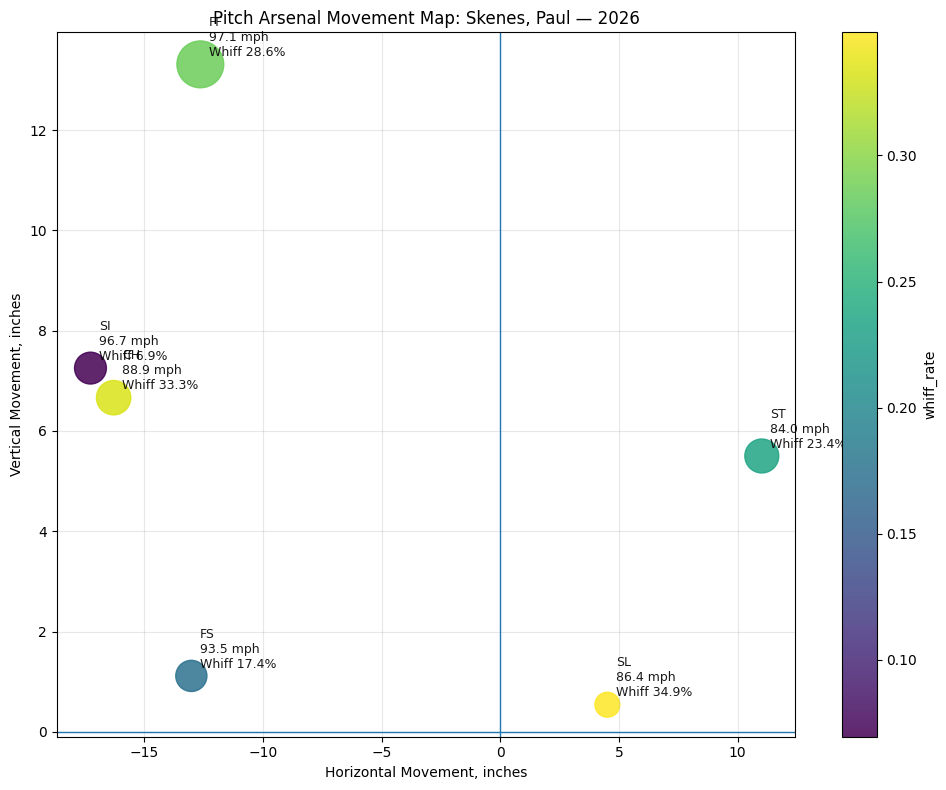

,player_name,pitch_type,pitches,_usage,avg_release_speed,whiff_rate,csw_rate,avg_pfx_x,avg_pfx_z
6521,"Skenes, Paul",FF,503,0.374814,97.105169,0.285714,0.286282,-1.052545,1.109245
6522,"Skenes, Paul",CH,222,0.165425,88.868018,0.333333,0.207207,-1.356802,0.555315
6523,"Skenes, Paul",ST,214,0.159463,84.02243,0.233766,0.308411,0.91785,0.458411
6524,"Skenes, Paul",SI,175,0.130402,96.713143,0.069444,0.297143,-1.438057,0.604457
6525,"Skenes, Paul",FS,163,0.121461,93.510429,0.173913,0.208589,-1.084049,0.092945
6526,"Skenes, Paul",SL,65,0.048435,86.403077,0.348837,0.307692,0.375846,0.045077


In [32]:
plot_pitcher_arsenal_map(
    pitch_summary,
    pitcher_name="Skenes, Paul",
    season=2026,
    min_pitches=25,
)

In [33]:
plot_pitcher_arsenal_map(pitch_summary, "Skenes, Pauls", season=2026)
#plot_pitcher_arsenal_map(pitch_summary, "Gerrit Cole", season=2025)
#plot_pitcher_arsenal_map(pitch_summary, "Zack Wheeler", season=2026)

AssertionError: No rows found for pitcher=Skenes, Pauls, season=2026

In [34]:
def plot_pitcher_weapon_quadrant(
    pitch_summary,
    pitcher_name,
    season=None,
    min_pitches=25,
    metric="whiff_rate",
):
    d = pitch_summary.copy()

    name_col = _find_col(d, ["player_name", "pitcher_name", "name"])
    pitch_col = _find_col(d, ["pitch_type", "pitch_name"])
    pitches_col = _find_col(d, ["pitches", "n_pitches", "pitch_count"])
    velo_col = _find_col(d, ["avg_release_speed", "release_speed_mean", "mean_release_speed"])

    if metric not in d.columns:
        metric = _find_col(d, ["whiff_rate", "csw_rate"])

    assert metric is not None, "No whiff_rate or csw_rate column found."

    d = d[d[name_col].astype(str).str.contains(pitcher_name, case=False, na=False)].copy()

    if season is not None and "season" in d.columns:
        d = d[d["season"].eq(season)].copy()

    d = d[pd.to_numeric(d[pitches_col], errors="coerce") >= min_pitches].copy()

    assert len(d) > 0, f"No rows found for pitcher={pitcher_name}, season={season}"

    d[pitches_col] = pd.to_numeric(d[pitches_col], errors="coerce")
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d["_usage"] = d[pitches_col] / d[pitches_col].sum()

    if velo_col is not None:
        d[velo_col] = pd.to_numeric(d[velo_col], errors="coerce")
        d["_size"] = 80 + 10 * d[velo_col].fillna(d[velo_col].median())
    else:
        d["_size"] = 180

    fig, ax = plt.subplots(figsize=(10, 7))

    ax.scatter(
        d["_usage"],
        d[metric],
        s=d["_size"],
        alpha=0.85,
    )

    ax.axvline(d["_usage"].mean(), linestyle="--", linewidth=1)
    ax.axhline(d[metric].mean(), linestyle="--", linewidth=1)

    for _, row in d.iterrows():
        label = str(row[pitch_col])

        if velo_col is not None and pd.notna(row.get(velo_col)):
            label += f"\n{row[velo_col]:.1f}"

        ax.annotate(
            label,
            (row["_usage"], row[metric]),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9,
        )

    title_season = f" — {season}" if season is not None else ""
    ax.set_title(f"Pitch Usage vs {metric}: {pitcher_name}{title_season}")
    ax.set_xlabel("Pitch Usage Share")
    ax.set_ylabel(metric)
    ax.set_xlim(0, max(0.6, d["_usage"].max() + 0.05))
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(
        d[
            [name_col, pitch_col, pitches_col, "_usage", metric]
            + ([velo_col] if velo_col is not None else [])
        ]
        .sort_values(metric, ascending=False)
    )

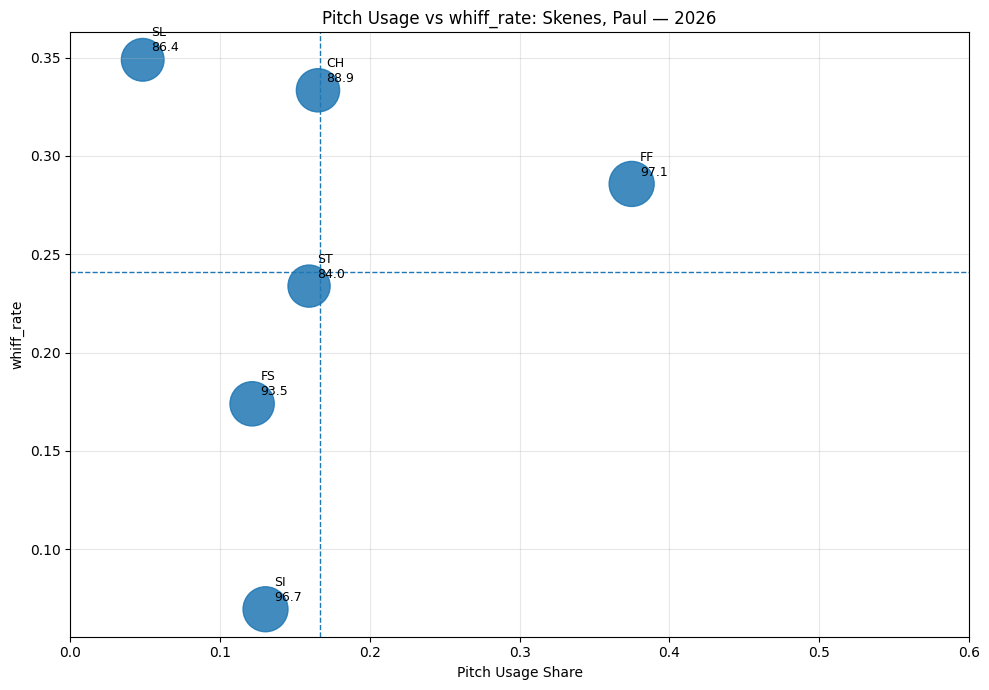

,player_name,pitch_type,pitches,_usage,whiff_rate,avg_release_speed
6526,"Skenes, Paul",SL,65,0.048435,0.348837,86.403077
6522,"Skenes, Paul",CH,222,0.165425,0.333333,88.868018
6521,"Skenes, Paul",FF,503,0.374814,0.285714,97.105169
6523,"Skenes, Paul",ST,214,0.159463,0.233766,84.02243
6525,"Skenes, Paul",FS,163,0.121461,0.173913,93.510429
6524,"Skenes, Paul",SI,175,0.130402,0.069444,96.713143


In [35]:
plot_pitcher_weapon_quadrant(
    pitch_summary,
    "Skenes, Paul",
    season=2026,
    metric="whiff_rate",
)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_pitch_movement_by_type(
    statcast_raw,
    pitcher_name,
    season=None,
    min_pitches_per_type=20,
    show_individual_pitches=True,
):
    d = statcast_raw.copy()

    required_cols = [
        "player_name",
        "pitch_type",
        "pfx_x",
        "pfx_z",
        "release_speed",
    ]

    missing = [c for c in required_cols if c not in d.columns]
    assert not missing, f"Missing required columns: {missing}"

    # Date/season handling
    if "game_date" in d.columns:
        d["game_date"] = pd.to_datetime(d["game_date"], errors="coerce")
        d["season"] = d["game_date"].dt.year
    elif "official_date" in d.columns:
        d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")
        d["season"] = d["official_date"].dt.year

    # Filter pitcher
    d = d[
        d["player_name"].astype(str).str.contains(pitcher_name, case=False, na=False)
    ].copy()

    if season is not None and "season" in d.columns:
        d = d[d["season"].eq(season)].copy()

    d = d.dropna(subset=["pitch_type", "pfx_x", "pfx_z"]).copy()

    assert len(d) > 0, f"No pitch rows found for pitcher={pitcher_name}, season={season}"

    # Statcast pfx_x/pfx_z are usually in feet. Convert to inches.
    d["horizontal_movement_inches"] = pd.to_numeric(d["pfx_x"], errors="coerce") * 12
    d["vertical_movement_inches"] = pd.to_numeric(d["pfx_z"], errors="coerce") * 12
    d["release_speed"] = pd.to_numeric(d["release_speed"], errors="coerce")

    # Pitch-type summary
    pitch_summary = (
        d.groupby("pitch_type")
        .agg(
            pitches=("pitch_type", "count"),
            avg_horizontal_movement=("horizontal_movement_inches", "mean"),
            avg_vertical_movement=("vertical_movement_inches", "mean"),
            avg_velocity=("release_speed", "mean"),
        )
        .reset_index()
    )

    pitch_summary = pitch_summary[
        pitch_summary["pitches"] >= min_pitches_per_type
    ].copy()

    keep_pitch_types = pitch_summary["pitch_type"].tolist()
    d = d[d["pitch_type"].isin(keep_pitch_types)].copy()

    pitch_summary["usage"] = pitch_summary["pitches"] / pitch_summary["pitches"].sum()
    pitch_summary["dot_size"] = 250 + 2500 * pitch_summary["usage"]

    fig, ax = plt.subplots(figsize=(10, 8))

    pitch_types = sorted(keep_pitch_types)

    # Plot individual pitch cloud
    if show_individual_pitches:
        for pt in pitch_types:
            g = d[d["pitch_type"].eq(pt)]
            ax.scatter(
                g["horizontal_movement_inches"],
                g["vertical_movement_inches"],
                s=12,
                alpha=0.15,
                label=None,
            )

    # Plot pitch-type averages
    for pt in pitch_types:
        row = pitch_summary[pitch_summary["pitch_type"].eq(pt)].iloc[0]

        ax.scatter(
            row["avg_horizontal_movement"],
            row["avg_vertical_movement"],
            s=row["dot_size"],
            alpha=0.9,
            edgecolors="black",
            linewidths=1,
            label=pt,
        )

        label = (
            f"{pt}\n"
            f"{row['avg_velocity']:.1f} mph\n"
            f"{row['usage']:.1%}"
        )

        ax.annotate(
            label,
            (row["avg_horizontal_movement"], row["avg_vertical_movement"]),
            xytext=(8, 8),
            textcoords="offset points",
            fontsize=9,
            weight="bold",
        )

    title_season = f" — {season}" if season is not None else ""

    ax.set_title(f"Pitch Movement by Pitch Type: {pitcher_name}{title_season}")
    ax.set_xlabel("Horizontal Movement, inches")
    ax.set_ylabel("Vertical Movement, inches")

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(True, alpha=0.3)

    ax.legend(title="Pitch Type", loc="best")
    plt.tight_layout()
    plt.show()

    display(
        pitch_summary
        .sort_values("usage", ascending=False)
        .drop(columns=["dot_size"])
    )

    return pitch_summary

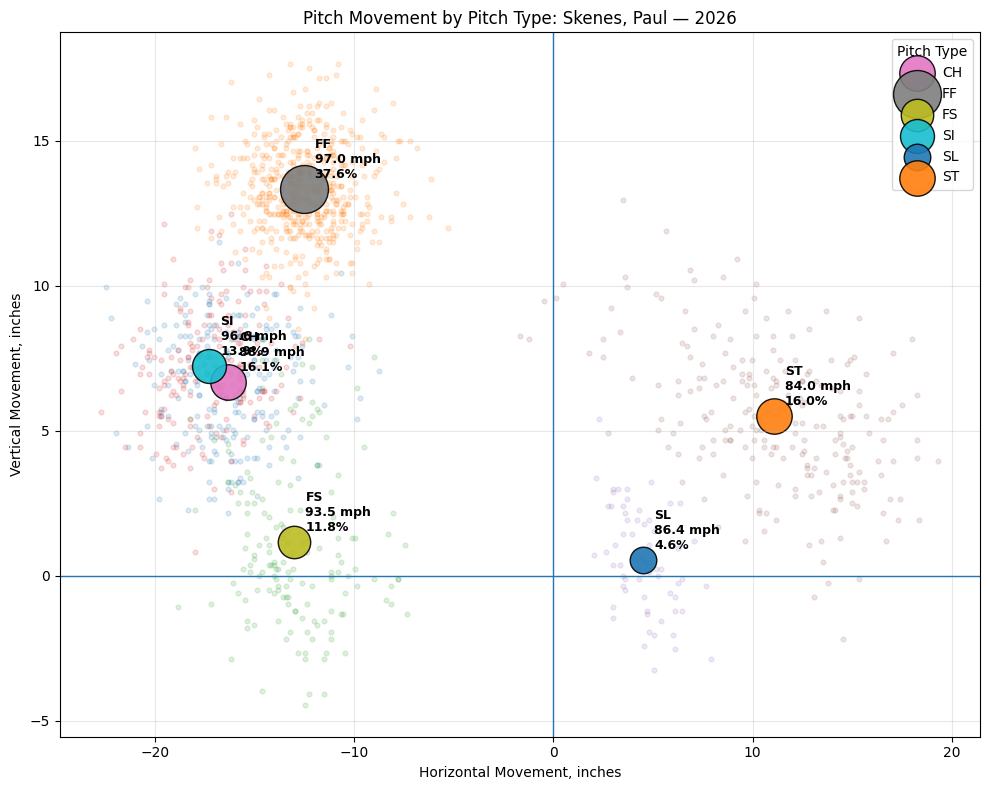

,pitch_type,pitches,avg_horizontal_movement,avg_vertical_movement,avg_velocity,usage
2,FF,527,-12.536471,13.34778,97.034725,0.376160
0,CH,225,-16.3216,6.671467,88.858222,0.160600
6,ST,224,11.072143,5.503393,83.974554,0.159886
4,SI,195,-17.262154,7.230769,96.608205,0.139186
3,FS,165,-12.999273,1.183273,93.511515,0.117773
5,SL,65,4.510154,0.540923,86.403077,0.046395


,pitch_type,pitches,avg_horizontal_movement,avg_vertical_movement,avg_velocity,usage,dot_size
0,CH,225,-16.3216,6.671467,88.858222,0.160600,651.498929
2,FF,527,-12.536471,13.34778,97.034725,0.376160,1190.399714
3,FS,165,-12.999273,1.183273,93.511515,0.117773,544.432548
4,SI,195,-17.262154,7.230769,96.608205,0.139186,597.965739
5,SL,65,4.510154,0.540923,86.403077,0.046395,365.988580
6,ST,224,11.072143,5.503393,83.974554,0.159886,649.714490


In [37]:
plot_pitch_movement_by_type(
    statcast_raw,
    pitcher_name="Skenes, Paul",
    season=2026,
    min_pitches_per_type=25,
)

Higher on the chart means the pitch has more “ride” or less drop. Lower means more drop. Farther left/right means more horizontal movement.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_pitch_movement_with_damage(
    statcast_raw,
    pitcher_name,
    season=None,
    min_pitches_per_type=25,
    damage_metric="woba_allowed",  # "woba_allowed", "xwoba_allowed", "run_value_per_100", "runs_per_100_pa"
    show_individual_pitches=True,
):
    d = statcast_raw.copy()

    required_cols = [
        "player_name",
        "pitch_type",
        "pfx_x",
        "pfx_z",
        "release_speed",
    ]

    missing = [c for c in required_cols if c not in d.columns]
    assert not missing, f"Missing required columns: {missing}"

    # Season handling
    if "game_date" in d.columns:
        d["game_date"] = pd.to_datetime(d["game_date"], errors="coerce")
        d["season"] = d["game_date"].dt.year
    elif "official_date" in d.columns:
        d["official_date"] = pd.to_datetime(d["official_date"], errors="coerce")
        d["season"] = d["official_date"].dt.year

    # Filter pitcher
    d = d[
        d["player_name"].astype(str).str.contains(pitcher_name, case=False, na=False)
    ].copy()

    if season is not None and "season" in d.columns:
        d = d[d["season"].eq(season)].copy()

    d = d.dropna(subset=["pitch_type", "pfx_x", "pfx_z"]).copy()

    assert len(d) > 0, f"No pitch rows found for pitcher={pitcher_name}, season={season}"

    # Movement in inches
    d["horizontal_movement_inches"] = pd.to_numeric(d["pfx_x"], errors="coerce") * 12
    d["vertical_movement_inches"] = pd.to_numeric(d["pfx_z"], errors="coerce") * 12
    d["release_speed"] = pd.to_numeric(d["release_speed"], errors="coerce")

    # Plate appearance ending pitch
    if "events" in d.columns:
        d["is_pa_end"] = d["events"].notna()
    else:
        d["is_pa_end"] = False

    # Whiff / CSW
    if "description" in d.columns:
        desc = d["description"].astype(str)

        d["is_whiff"] = desc.isin([
            "swinging_strike",
            "swinging_strike_blocked",
            "foul_tip",
        ])

        d["is_csw"] = desc.isin([
            "called_strike",
            "swinging_strike",
            "swinging_strike_blocked",
            "foul_tip",
        ])
    else:
        d["is_whiff"] = np.nan
        d["is_csw"] = np.nan

    # Actual batting-team runs scored on the play, if available.
    # This is NOT earned runs. It is a damage proxy.
    if {"post_bat_score", "bat_score"}.issubset(d.columns):
        d["runs_on_play"] = (
            pd.to_numeric(d["post_bat_score"], errors="coerce")
            - pd.to_numeric(d["bat_score"], errors="coerce")
        ).clip(lower=0)
    else:
        d["runs_on_play"] = np.nan

    agg_dict = {
        "pitches": ("pitch_type", "count"),
        "pa_endings": ("is_pa_end", "sum"),
        "avg_horizontal_movement": ("horizontal_movement_inches", "mean"),
        "avg_vertical_movement": ("vertical_movement_inches", "mean"),
        "avg_velocity": ("release_speed", "mean"),
        "whiff_rate": ("is_whiff", "mean"),
        "csw_rate": ("is_csw", "mean"),
    }

    if "woba_value" in d.columns:
        d["woba_value"] = pd.to_numeric(d["woba_value"], errors="coerce")
        agg_dict["woba_allowed"] = ("woba_value", "mean")

    if "estimated_woba_using_speedangle" in d.columns:
        d["estimated_woba_using_speedangle"] = pd.to_numeric(
            d["estimated_woba_using_speedangle"],
            errors="coerce",
        )
        agg_dict["xwoba_allowed"] = ("estimated_woba_using_speedangle", "mean")

    if "delta_run_exp" in d.columns:
        d["delta_run_exp"] = pd.to_numeric(d["delta_run_exp"], errors="coerce")
        agg_dict["run_value_total"] = ("delta_run_exp", "sum")

    if "runs_on_play" in d.columns:
        agg_dict["runs_allowed_on_pa_end"] = ("runs_on_play", "sum")

    pitch_summary = (
        d.groupby("pitch_type")
        .agg(**agg_dict)
        .reset_index()
    )

    pitch_summary = pitch_summary[
        pitch_summary["pitches"] >= min_pitches_per_type
    ].copy()

    pitch_summary["usage"] = pitch_summary["pitches"] / pitch_summary["pitches"].sum()

    if "run_value_total" in pitch_summary.columns:
        pitch_summary["run_value_per_100"] = (
            pitch_summary["run_value_total"] / pitch_summary["pitches"] * 100
        )

    if "runs_allowed_on_pa_end" in pitch_summary.columns:
        pitch_summary["runs_per_100_pa"] = (
            pitch_summary["runs_allowed_on_pa_end"]
            / pitch_summary["pa_endings"].replace(0, np.nan)
            * 100
        )

    assert damage_metric in pitch_summary.columns, (
        f"{damage_metric} not available. Available columns include: "
        f"{pitch_summary.columns.tolist()}"
    )

    keep_pitch_types = pitch_summary["pitch_type"].tolist()
    d = d[d["pitch_type"].isin(keep_pitch_types)].copy()

    pitch_summary["dot_size"] = 250 + 2500 * pitch_summary["usage"]

    fig, ax = plt.subplots(figsize=(11, 8))

    # Individual pitch cloud
    if show_individual_pitches:
        for pt in sorted(keep_pitch_types):
            g = d[d["pitch_type"].eq(pt)]
            ax.scatter(
                g["horizontal_movement_inches"],
                g["vertical_movement_inches"],
                s=12,
                alpha=0.12,
            )

    # Average bubbles colored by damage
    scatter = ax.scatter(
        pitch_summary["avg_horizontal_movement"],
        pitch_summary["avg_vertical_movement"],
        s=pitch_summary["dot_size"],
        c=pitch_summary[damage_metric],
        alpha=0.90,
        edgecolors="black",
        linewidths=1,
    )

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(damage_metric)

    for _, row in pitch_summary.iterrows():
      label = (
      f"{row['pitch_type']}\n"
      f"{row['avg_velocity']:.1f} mph\n"
      f"{row['usage']:.1%}\n"
      f"{damage_metric}: {row[damage_metric]:.2f}"
      )

      if "pa_endings" in row.index:
          label += f"\nPA: {int(row['pa_endings'])}"
          ax.annotate(
              label,
              (row["avg_horizontal_movement"], row["avg_vertical_movement"]),
              xytext=(8, 8),
              textcoords="offset points",
              fontsize=9,
              weight="bold",
          )

    title_season = f" — {season}" if season is not None else ""

    ax.set_title(
        f"Pitch Movement + Damage by Pitch Type: {pitcher_name}{title_season}\n"
        f"Bubble size = usage, color = {damage_metric}"
    )
    ax.set_xlabel("Horizontal Movement, inches")
    ax.set_ylabel("Vertical Movement, inches")

    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    display(
        pitch_summary
        .sort_values(damage_metric, ascending=True)
        .drop(columns=["dot_size"])
    )

    return pitch_summary

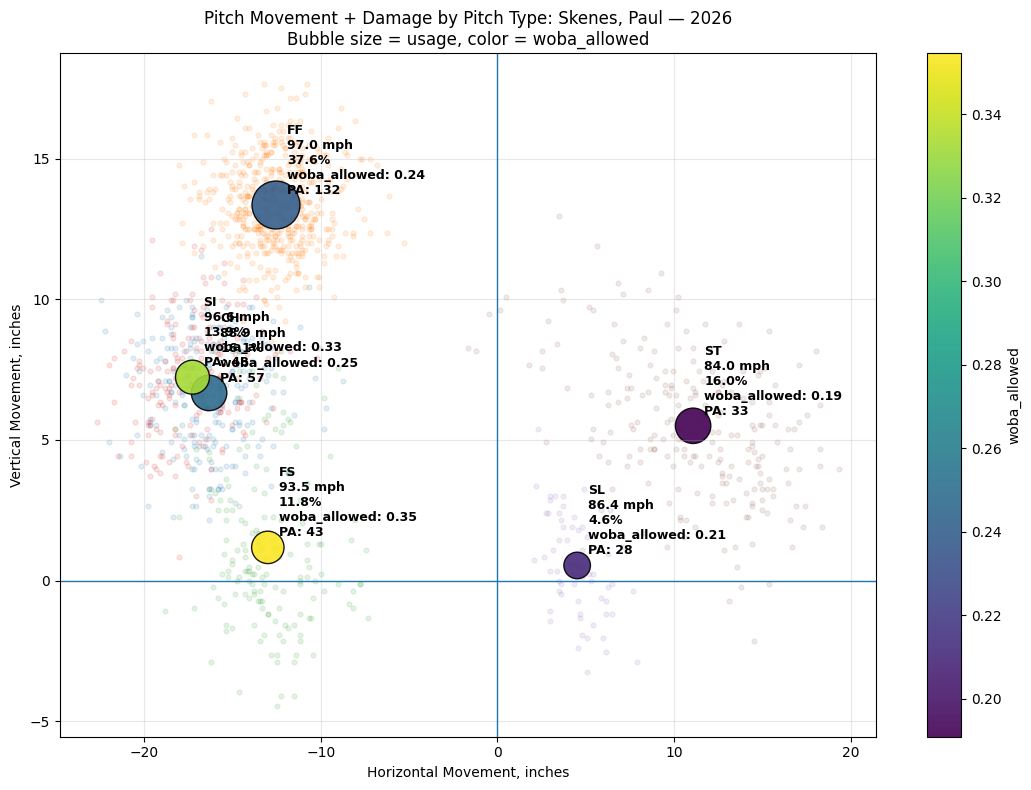

,pitch_type,pitches,pa_endings,avg_horizontal_movement,avg_vertical_movement,avg_velocity,whiff_rate,csw_rate,woba_allowed,xwoba_allowed,run_value_total,runs_allowed_on_pa_end,usage,run_value_per_100,runs_per_100_pa
6,ST,224,33,11.072143,5.503393,83.974554,0.102679,0.316964,0.190909,0.214111,-2.573,3,0.159886,-1.148661,9.090909
5,SL,65,28,4.510154,0.540923,86.403077,0.292308,0.369231,0.210714,0.195865,-2.557,1,0.046395,-3.933846,3.571429
2,FF,527,132,-12.536471,13.34778,97.034725,0.172676,0.303605,0.239773,0.2491,-10.419,8,0.376160,-1.97704,6.060606
0,CH,225,57,-16.3216,6.671467,88.858222,0.186667,0.222222,0.248246,0.217885,1.586,8,0.160600,0.704889,14.035088
4,SI,195,48,-17.262154,7.230769,96.608205,0.030769,0.287179,0.332292,0.326669,-1.68,5,0.139186,-0.861538,10.416667
3,FS,165,43,-12.999273,1.183273,93.511515,0.103030,0.212121,0.354651,0.274377,-0.69,3,0.117773,-0.418182,6.976744


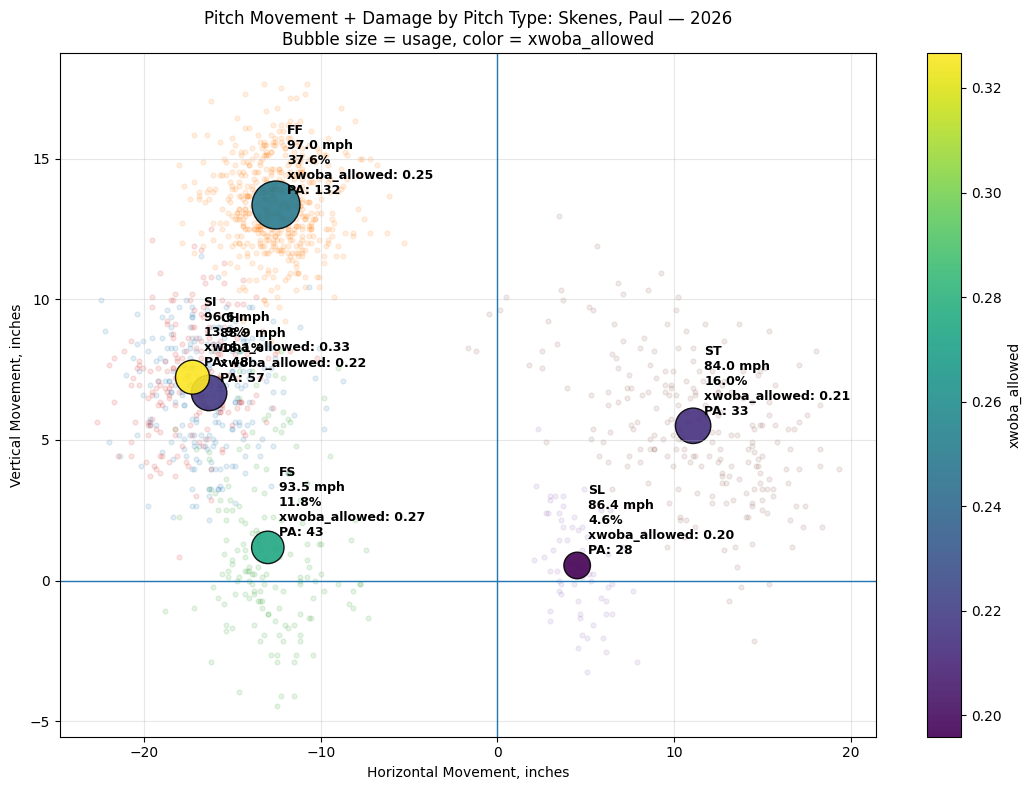

,pitch_type,pitches,pa_endings,avg_horizontal_movement,avg_vertical_movement,avg_velocity,whiff_rate,csw_rate,woba_allowed,xwoba_allowed,run_value_total,runs_allowed_on_pa_end,usage,run_value_per_100,runs_per_100_pa
5,SL,65,28,4.510154,0.540923,86.403077,0.292308,0.369231,0.210714,0.195865,-2.557,1,0.046395,-3.933846,3.571429
6,ST,224,33,11.072143,5.503393,83.974554,0.102679,0.316964,0.190909,0.214111,-2.573,3,0.159886,-1.148661,9.090909
0,CH,225,57,-16.3216,6.671467,88.858222,0.186667,0.222222,0.248246,0.217885,1.586,8,0.160600,0.704889,14.035088
2,FF,527,132,-12.536471,13.34778,97.034725,0.172676,0.303605,0.239773,0.2491,-10.419,8,0.376160,-1.97704,6.060606
3,FS,165,43,-12.999273,1.183273,93.511515,0.103030,0.212121,0.354651,0.274377,-0.69,3,0.117773,-0.418182,6.976744
4,SI,195,48,-17.262154,7.230769,96.608205,0.030769,0.287179,0.332292,0.326669,-1.68,5,0.139186,-0.861538,10.416667


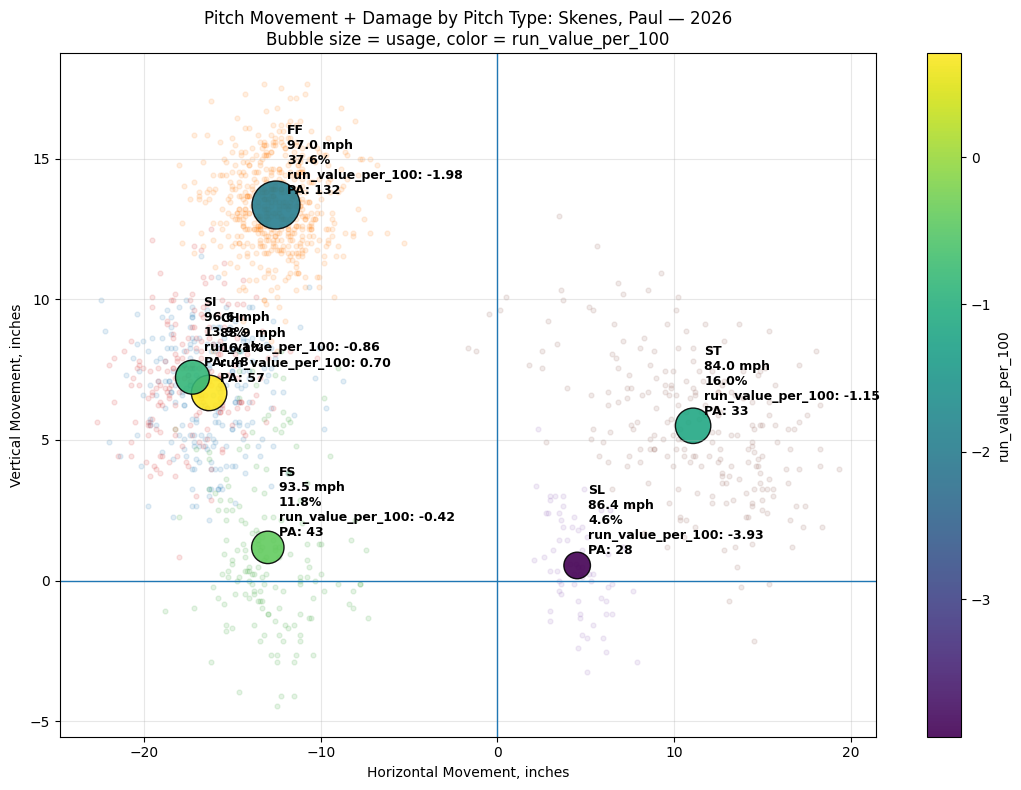

,pitch_type,pitches,pa_endings,avg_horizontal_movement,avg_vertical_movement,avg_velocity,whiff_rate,csw_rate,woba_allowed,xwoba_allowed,run_value_total,runs_allowed_on_pa_end,usage,run_value_per_100,runs_per_100_pa
5,SL,65,28,4.510154,0.540923,86.403077,0.292308,0.369231,0.210714,0.195865,-2.557,1,0.046395,-3.933846,3.571429
2,FF,527,132,-12.536471,13.34778,97.034725,0.172676,0.303605,0.239773,0.2491,-10.419,8,0.376160,-1.97704,6.060606
6,ST,224,33,11.072143,5.503393,83.974554,0.102679,0.316964,0.190909,0.214111,-2.573,3,0.159886,-1.148661,9.090909
4,SI,195,48,-17.262154,7.230769,96.608205,0.030769,0.287179,0.332292,0.326669,-1.68,5,0.139186,-0.861538,10.416667
3,FS,165,43,-12.999273,1.183273,93.511515,0.103030,0.212121,0.354651,0.274377,-0.69,3,0.117773,-0.418182,6.976744
0,CH,225,57,-16.3216,6.671467,88.858222,0.186667,0.222222,0.248246,0.217885,1.586,8,0.160600,0.704889,14.035088


,pitch_type,pitches,pa_endings,avg_horizontal_movement,avg_vertical_movement,avg_velocity,whiff_rate,csw_rate,woba_allowed,xwoba_allowed,run_value_total,runs_allowed_on_pa_end,usage,run_value_per_100,runs_per_100_pa,dot_size
0,CH,225,57,-16.3216,6.671467,88.858222,0.186667,0.222222,0.248246,0.217885,1.586,8,0.160600,0.704889,14.035088,651.498929
2,FF,527,132,-12.536471,13.34778,97.034725,0.172676,0.303605,0.239773,0.2491,-10.419,8,0.376160,-1.97704,6.060606,1190.399714
3,FS,165,43,-12.999273,1.183273,93.511515,0.103030,0.212121,0.354651,0.274377,-0.69,3,0.117773,-0.418182,6.976744,544.432548
4,SI,195,48,-17.262154,7.230769,96.608205,0.030769,0.287179,0.332292,0.326669,-1.68,5,0.139186,-0.861538,10.416667,597.965739
5,SL,65,28,4.510154,0.540923,86.403077,0.292308,0.369231,0.210714,0.195865,-2.557,1,0.046395,-3.933846,3.571429,365.988580
6,ST,224,33,11.072143,5.503393,83.974554,0.102679,0.316964,0.190909,0.214111,-2.573,3,0.159886,-1.148661,9.090909,649.714490


In [47]:
plot_pitch_movement_with_damage(
    statcast_raw,
    pitcher_name="Skenes, Paul",
    season=2026,
    damage_metric="woba_allowed",
)

plot_pitch_movement_with_damage(
    statcast_raw,
    pitcher_name="Skenes, Paul",
    season=2026,
    damage_metric="xwoba_allowed",
)

plot_pitch_movement_with_damage(
    statcast_raw,
    pitcher_name="Skenes, Paul",
    season=2026,
    damage_metric="run_value_per_100",
)